<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_67_kmeans_clustering_demo/Lecture_67_kmeans_clustering_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/student_clustering.csv')
# Print the shape of the DataFrame and display the first few rows
print('The shape of data is', df.shape)
df.head()

The shape of data is (200, 2)


,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


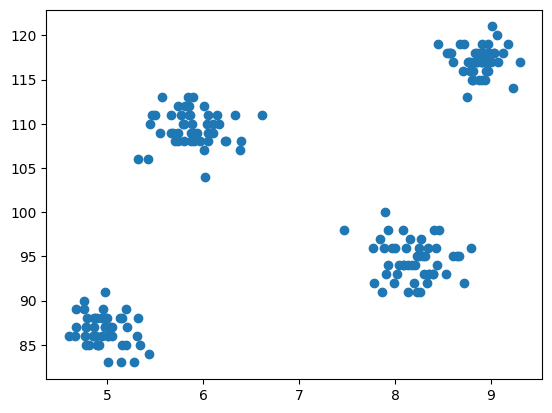

In [3]:
import matplotlib.pyplot as plt
# Create a scatter plot of 'cgpa' vs 'iq'
plt.scatter(df['cgpa'], df['iq'])

In [4]:
# Import the KMeans clustering algorithm from scikit-learn
from sklearn.cluster import KMeans

In [5]:
# Calculate the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters
wcss = []
for i in range(1, 11):
  # Initialize KMeans with i clusters
  km = KMeans(n_clusters=i)
  # Fit the model and predict the clusters
  km.fit_predict(df)
  # Append the inertia (WCSS) to the list
  wcss.append(km.inertia_)

In [6]:
# Display the calculated WCSS values
wcss

[29957.898287999997,
 4184.141269999999,
 2503.3975810000015,
 681.9696600000001,
 523.7131894763968,
 388.8524026875981,
 407.2356482608698,
 320.5151980456054,
 207.6471825272872,
 176.91425170951229]

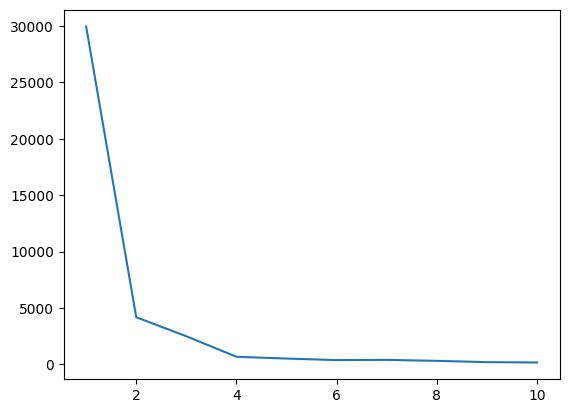

In [7]:
# Plot the WCSS values against the number of clusters to find the elbow point
plt.plot(range(1, 11), wcss)
# Show the plot
plt.show()

In [8]:
# Select all columns as features
X = df.iloc[:,:].values
# Initialize KMeans with 4 clusters (based on the elbow plot)
km = KMeans(n_clusters=4)
# Fit the model and predict the clusters for each data point
y_mean = km.fit_predict(X)

In [9]:
# Display the predicted cluster labels for each data point
y_mean

array([2, 3, 1, 1, 3, 3, 1, 0, 3, 1, 2, 3, 1, 2, 3, 1, 3, 1, 3, 3, 1, 2,
       1, 2, 2, 1, 2, 0, 1, 3, 0, 3, 0, 3, 1, 1, 0, 3, 2, 3, 2, 1, 1, 2,
       0, 0, 1, 3, 0, 3, 2, 2, 0, 1, 0, 3, 3, 0, 3, 0, 3, 1, 1, 0, 2, 0,
       1, 2, 3, 1, 3, 0, 1, 2, 3, 0, 3, 0, 2, 1, 1, 0, 3, 2, 0, 2, 0, 3,
       0, 3, 0, 0, 1, 2, 1, 1, 0, 1, 2, 0, 3, 2, 2, 0, 2, 2, 1, 2, 0, 0,
       1, 0, 3, 3, 1, 0, 1, 3, 0, 2, 2, 3, 1, 0, 1, 2, 1, 3, 2, 1, 1, 3,
       2, 2, 3, 0, 3, 2, 1, 1, 1, 2, 3, 2, 2, 0, 2, 0, 3, 2, 0, 2, 0, 0,
       2, 1, 3, 0, 3, 1, 2, 0, 3, 1, 0, 2, 3, 2, 2, 0, 0, 3, 0, 2, 2, 1,
       0, 3, 2, 0, 0, 3, 3, 3, 1, 2, 1, 1, 0, 3, 1, 1, 2, 2, 1, 2, 0, 3,
       3, 0], dtype=int32)

In [10]:
# Access and display the 'iq' values for data points in cluster 3
X[y_mean == 3,1]

array([113., 110., 109., 110., 110., 108., 111., 111., 113., 106., 112.,
       106., 108., 113., 108., 109., 108., 111., 109., 104., 111., 109.,
       109., 112., 111., 109., 108., 110., 109., 111., 108., 109., 109.,
       111., 112., 109., 111., 107., 111., 110., 108., 109., 110., 108.,
       108., 110., 107., 111., 112., 108.])

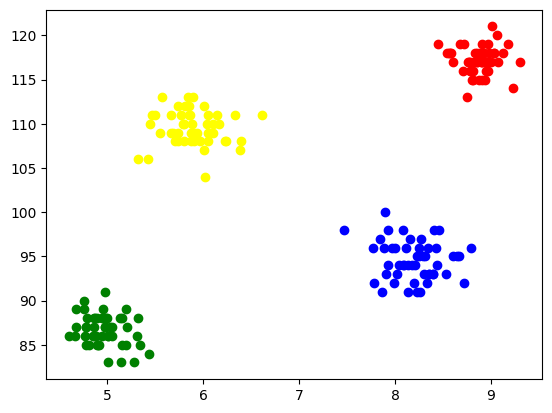

In [11]:
# Create a scatter plot with different colors for each cluster
plt.scatter(X[y_mean == 0,0], X[y_mean == 0,1], c='red')
plt.scatter(X[y_mean == 1,0], X[y_mean == 1,1], c='blue')
plt.scatter(X[y_mean == 2,0], X[y_mean == 2,1], c='green')
plt.scatter(X[y_mean == 3,0], X[y_mean == 3,1], c='yellow')
# Show the plot
plt.show()

#**K-Means on 3-D Data**

In [12]:
# Generate synthetic 3D data using make_blobs
from sklearn.datasets import make_blobs
# Define the center points for the clusters
centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
# Define the standard deviation for each cluster
cluster_std = [1, 1, 1, 1]

# Create the blobs of data
X, y = make_blobs(n_samples=200, centers=centroids, cluster_std=cluster_std, n_features=3, random_state=1)

In [13]:
# Display the generated 3D data
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [22]:
import plotly.express as px
# Create a 3D scatter plot of the generated data
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
# Show the plot
fig.show()

In [15]:
# Calculate the WCSS for different numbers of clusters (1 to 20) for the 3D data
wcss = []
for i in range(1, 21):
  # Initialize KMeans with i clusters
  km = KMeans(n_clusters=i)
  # Fit the model and predict the clusters
  km.fit_predict(X)
  # Append the inertia (WCSS) to the list
  wcss.append(km.inertia_)

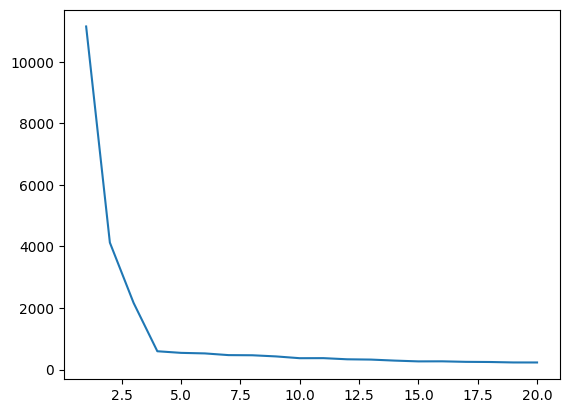

In [16]:
# Plot the WCSS values against the number of clusters for the 3D data
plt.plot(range(1, 21), wcss)
# Show the plot
plt.show()

In [19]:
# Initialize KMeans with 4 clusters (based on the elbow plot for 3D data)
km = KMeans(n_clusters=4)
# Fit the model and predict the clusters for the 3D data
y_pred = km.fit_predict(X)

In [20]:
# Create a new DataFrame to store the 3D data and cluster labels
df = pd.DataFrame()
df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [21]:
# Create a 3D scatter plot of the 3D data, colored by the cluster labels
fig = px.scatter_3d(df, x='col1', y='col2', z='col3', color='label')
# Show the plot
fig.show()